# 13. Explanation Stability Across Resamples and Retrains

The previous notebook explained ranked action queues. This notebook asks a different question:

> If we rerun the modeling process tomorrow, will the explanation still say the same thing?

This is one of the most important practical questions in XAI. A model explanation can look precise while being unstable. Feature importance rankings can reorder across bootstrap samples. Local explanations can flip signs for near-boundary cases. Partial dependence curves can change shape after retraining. A stakeholder may not notice this instability if we only show one polished explanation from one fitted model.

In decision systems, unstable explanations create more than an aesthetic problem. They weaken auditability. They make governance reviews harder. They can lead teams to communicate a narrative that is more fragile than the model's predictive performance suggests.

## Learning Objectives

By the end of this notebook, you should be able to:

1. Treat explanations as estimates with sampling and training variability.
2. Measure stability of global feature-importance rankings across resamples.
3. Compare model performance stability with explanation stability.
4. Diagnose local explanation sign changes for a focal decision.
5. Build partial-dependence stability bands across retrained models.
6. Identify near-equivalent models with different explanations.
7. Produce a professional explanation-stability report for governance.

## 1. Explanations Are Stochastic Objects

Let $\widehat f_b$ be a model trained on resample $b$ of the data. Let $E(\widehat f_b, D, x)$ be an explanation computed from that model, a dataset $D$, and possibly a focal case $x$. Examples include:

- permutation importance for feature $j$;
- a local surrogate coefficient for feature $j$;
- a partial-dependence curve evaluated on a grid;
- a rank, score, or counterfactual recommendation.

The explanation is not a fixed truth. It is an output of a pipeline:

$$
\widehat e_b = E(\widehat f_b, D_b, x).
$$

Across resamples or retrains, we get a distribution

$$
\{\widehat e_1, \widehat e_2, \ldots, \widehat e_B\}.
$$

A stable explanation has small variation across that distribution. An unstable explanation changes enough that the communicated story depends on arbitrary training choices.

This connects to the **Rashomon effect**: many models can achieve similar predictive accuracy while relying on different features or producing different explanations. Rudin et al. (2022) discuss the Rashomon set as a central challenge for interpretable machine learning. Fisher, Rudin, and Dominici (2018) and Dong and Rudin (2019) motivate studying reliance or variable importance across sets of good models rather than trusting one fitted model. Hancox-Li (2020) argues that robustness matters for whether explanations reflect real patterns rather than artifacts.

## 2. Stability Metrics

We will use several diagnostics.

For two feature rankings $r_a$ and $r_b$, Spearman correlation measures rank agreement:

$$
\rho(r_a,r_b) = \operatorname{corr}\{r_a, r_b\}.
$$

For a top-$k$ set of features, the Jaccard overlap is

$$
J(A,B)=\frac{|A \cap B|}{|A \cup B|}.
$$

For a local explanation sign, the sign-agreement rate for feature $j$ is

$$
\operatorname{SignAgree}_j = \frac{1}{B}\sum_{b=1}^{B}\mathbb{1}\{\operatorname{sign}(e_{bj})=\operatorname{sign}(e_{0j})\}.
$$

For a curve $g_b(t)$, such as partial dependence at grid point $t$, we can report a stability band:

$$
\left[Q_{0.10}\{g_b(t)\}, Q_{0.90}\{g_b(t)\}\right].
$$

These are not the only possible metrics. They are operationally useful because they answer questions a governance reviewer can understand: are the same features important, do the signs agree, and are the curves consistent enough to communicate?

In [1]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy.stats import spearmanr
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 2083
sns.set_theme(style='whitegrid', context='notebook')
np.set_printoptions(precision=3, suppress=True)
pd.set_option('display.max_colwidth', 120)

In [2]:
# Section focus: 2. Stability Metrics.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def display_table(df, precision=3, max_width='520px'):
    """Display table for the 13. Explanation Stability Across Resamples and Retrains notebook output.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    precision : object
        Number of decimal places used when formatting numeric output.
    max_width : object
        Maximum display width used to keep rendered tables readable.
    
    Returns
    -------
    object
        None. The function updates a plot, display object, or notebook state as its side effect.
    """
    styler = df.style.format(precision=precision)
    styler = styler.set_table_styles([
        {'selector': 'th', 'props': [('white-space', 'normal'), ('text-align', 'left')]},
        {'selector': 'td', 'props': [('white-space', 'normal'), ('max-width', max_width), ('text-align', 'left'), ('vertical-align', 'top')]},
    ])
    display(styler)


def sigmoid(z):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    z : object
        Linear predictor or standardized score being transformed by this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-z))


def predict_risk(model, frame, features):
    """Carry out the predict risk step used in the 13. Explanation Stability Across Resamples and Retrains workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    frame : object
        Data frame containing the units evaluated by this helper.
    features : object
        Feature column names or feature matrix used by the model.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the predict risk calculation.
    """
    return model.predict_proba(frame[features])[:, 1]


def classification_metrics(y_true, pred):
    """Carry out the classification metrics step used in the 13. Explanation Stability Across Resamples and Retrains workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    pred : object
        The pred setting that controls the classification metrics calculation in this notebook.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    return {
        'roc_auc': roc_auc_score(y_true, pred),
        'average_precision': average_precision_score(y_true, pred),
        'brier_score': brier_score_loss(y_true, pred),
        'mean_predicted_risk': float(np.mean(pred)),
    }


def jaccard(a, b):
    """Carry out the jaccard step used in the 13. Explanation Stability Across Resamples and Retrains workflow.
    
    Parameters
    ----------
    a : object
        The a setting that controls the jaccard calculation in this notebook.
    b : object
        The b setting that controls the jaccard calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the jaccard calculation and reused by later cells.
    """
    a, b = set(a), set(b)
    return len(a & b) / len(a | b) if a | b else np.nan

This result is an interpretation diagnostic. For Stability Metrics, look at whether the explanation is stable, plausible, and useful for stakeholder review. Different conclusions under reasonable settings should keep the explanation in review.


## 3. Synthetic Decision Case: Retention Escalation

We will use a retention decision system. The model predicts whether an account will require escalation before renewal. Explanations are used by a customer-success operations team to decide what story to tell leadership:

- Is risk mainly about usage decline?
- Is it about ticket burden?
- Is it about billing friction?
- Is it about implementation complexity?

The data-generating process deliberately contains correlated drivers. This is important. Explanation instability is most visible when multiple correlated variables can substitute for each other.

Each row represents an account approaching renewal. The observed fields describe usage decline, ticket burden, training completion, billing friction, implementation complexity, and account value. The outcome marks whether the account will require escalation before renewal. This is a realistic setting for explanation stability because correlated operational signals can trade places across retrains.

The experiment is a retraining experiment. We repeatedly resample the training data, refit the model, and ask whether global importance, local explanations, and selected case narratives remain stable. If the explanation changes dramatically while predictive quality barely moves, the deployment packet should report explanation instability rather than present one explanation as definitive.


In [3]:
# Section focus: 3. Synthetic Decision Case: Retention Escalation.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def make_retention_data(n=6400, seed=RANDOM_SEED):
    """Construct the retention data helper used in the 13. Explanation Stability Across Resamples and Retrains workflow.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)

    account_size = rng.normal(0, 1, n)
    enterprise = rng.binomial(1, sigmoid(-0.35 + 0.82 * account_size), n)
    regulated_industry = rng.binomial(1, sigmoid(-0.90 + 0.45 * enterprise + 0.25 * account_size), n)
    executive_sponsor = rng.binomial(1, sigmoid(-0.10 + 0.70 * account_size - 0.28 * regulated_industry), n)

    maturity = rng.normal(0, 1, n) + 0.35 * executive_sponsor - 0.25 * regulated_industry
    usage_drop = np.clip(sigmoid(-0.25 - 0.85 * maturity + rng.normal(0, 0.72, n)), 0.02, 0.98)
    training_gap = np.clip(sigmoid(-0.20 - 0.70 * maturity + 0.62 * usage_drop + rng.normal(0, 0.62, n)), 0.02, 0.98)
    onboarding_delay = np.clip(rng.gamma(1.3 + 1.1 * regulated_industry + 0.75 * enterprise, 2.1, n), 0, 18)
    support_tickets = rng.poisson(np.clip(np.exp(0.25 + 0.92 * usage_drop + 0.45 * training_gap + 0.25 * regulated_industry), 0.2, 11))
    incident_count = rng.poisson(np.clip(np.exp(-1.25 + 0.22 * support_tickets + 0.55 * regulated_industry), 0.04, 7))
    billing_friction = np.clip(sigmoid(-1.00 + 0.45 * regulated_industry + 0.15 * support_tickets + rng.normal(0, 0.85, n)), 0.01, 0.99)
    competitor_intent = np.clip(sigmoid(-1.25 + 1.05 * usage_drop + 0.60 * billing_friction + rng.normal(0, 0.75, n)), 0.01, 0.99)
    implementation_complexity = np.clip(sigmoid(-0.30 + 0.70 * enterprise + 0.55 * regulated_industry + rng.normal(0, 0.65, n)), 0.02, 0.98)
    random_noise_feature = rng.normal(0, 1, n)

    logit = (
        -3.25
        + 1.40 * usage_drop
        + 1.05 * training_gap
        + 0.13 * support_tickets
        + 0.42 * incident_count
        + 0.95 * billing_friction
        + 1.12 * competitor_intent
        + 0.32 * onboarding_delay / 6
        + 0.62 * regulated_industry
        - 0.80 * executive_sponsor
        + 0.80 * usage_drop * competitor_intent
        + 0.55 * implementation_complexity * regulated_industry
    )

    escalation_risk = sigmoid(logit)
    escalation = rng.binomial(1, escalation_risk)

    return pd.DataFrame({
        'account_size': account_size,
        'enterprise': enterprise,
        'regulated_industry': regulated_industry,
        'executive_sponsor': executive_sponsor,
        'usage_drop': usage_drop,
        'training_gap': training_gap,
        'onboarding_delay': onboarding_delay,
        'support_tickets': support_tickets,
        'incident_count': incident_count,
        'billing_friction': billing_friction,
        'competitor_intent': competitor_intent,
        'implementation_complexity': implementation_complexity,
        'random_noise_feature': random_noise_feature,
        'true_escalation_risk': escalation_risk,
        'escalation': escalation,
    })


df = make_retention_data()
TARGET = 'escalation'
FEATURES = [
    'account_size', 'enterprise', 'regulated_industry', 'executive_sponsor',
    'usage_drop', 'training_gap', 'onboarding_delay', 'support_tickets',
    'incident_count', 'billing_friction', 'competitor_intent',
    'implementation_complexity', 'random_noise_feature'
]

train_df, test_df = train_test_split(df, test_size=0.32, random_state=RANDOM_SEED, stratify=df[TARGET])

summary = pd.DataFrame([
    {'quantity': 'Rows', 'value': len(df)},
    {'quantity': 'Train rows', 'value': len(train_df)},
    {'quantity': 'Test rows', 'value': len(test_df)},
    {'quantity': 'Escalation rate', 'value': df[TARGET].mean()},
    {'quantity': 'Correlation: usage drop and training gap', 'value': df[['usage_drop', 'training_gap']].corr().iloc[0, 1]},
    {'quantity': 'Correlation: support tickets and incident count', 'value': df[['support_tickets', 'incident_count']].corr().iloc[0, 1]},
    {'quantity': 'Correlation: billing friction and competitor intent', 'value': df[['billing_friction', 'competitor_intent']].corr().iloc[0, 1]},
])

display_table(summary)
display_table(df[FEATURES + [TARGET]].head(6))

,quantity,value
0,Rows,6400.000
1,Train rows,4352.000
2,Test rows,2048.000
3,Escalation rate,0.436
4,Correlation: usage drop and training gap,0.654
5,Correlation: support tickets and incident count,0.432
6,Correlation: billing friction and competitor intent,0.188


,account_size,enterprise,regulated_industry,executive_sponsor,usage_drop,training_gap,onboarding_delay,support_tickets,incident_count,billing_friction,competitor_intent,implementation_complexity,random_noise_feature,escalation
0,-0.338,1,0,0,0.486,0.475,5.668,1,0,0.537,0.513,0.761,-1.216,0
1,-0.052,1,0,0,0.132,0.315,3.279,2,1,0.474,0.274,0.504,0.230,1
2,1.060,1,0,1,0.261,0.708,3.165,2,1,0.407,0.268,0.610,1.652,0
3,-1.971,0,0,1,0.611,0.536,0.361,4,1,0.257,0.355,0.251,0.062,0
4,-0.409,1,1,0,0.668,0.778,10.509,3,0,0.368,0.141,0.768,-1.393,1
5,0.500,1,0,1,0.861,0.691,1.422,4,1,0.378,0.609,0.698,-1.610,1


Synthetic Decision Case: Retention Escalation should make the model story easier to inspect instead of merely more polished.


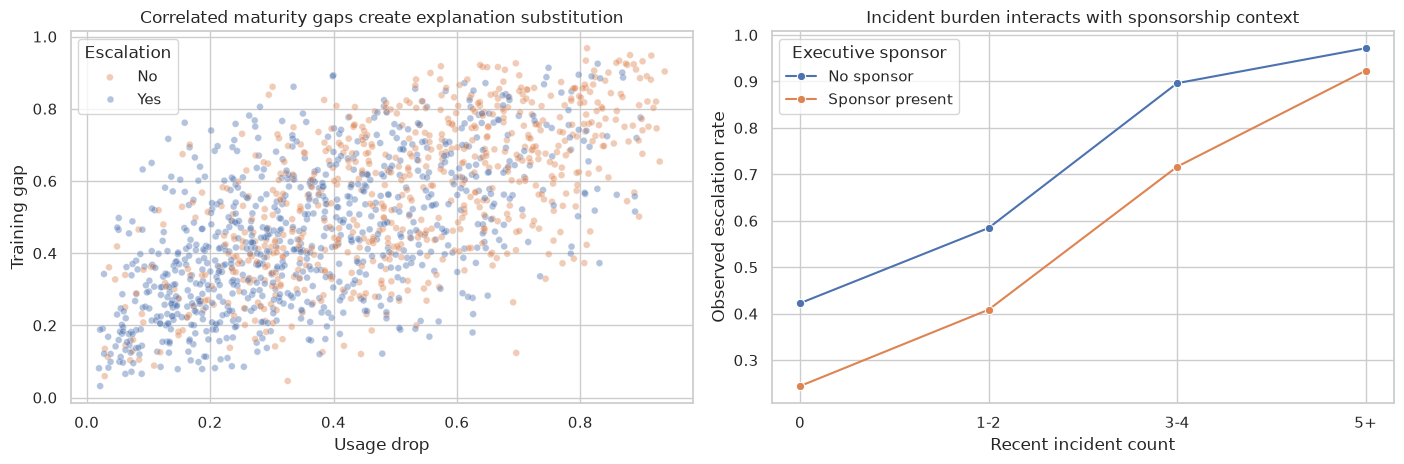

In [4]:
# Section focus: 3. Synthetic Decision Case: Retention Escalation.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(14.2, 4.8))

sample = df.sample(1500, random_state=RANDOM_SEED)
sns.scatterplot(
    data=sample,
    x='usage_drop',
    y='training_gap',
    hue='escalation',
    palette={0: '#4c72b0', 1: '#dd8452'},
    alpha=0.42,
    s=24,
    ax=axes[0],
)
axes[0].set_title('Correlated maturity gaps create explanation substitution')
axes[0].set_xlabel('Usage drop')
axes[0].set_ylabel('Training gap')
axes[0].legend(title='Escalation', labels=['No', 'Yes'])

incident_bins = pd.cut(df['incident_count'], bins=[-0.1, 0.5, 2.5, 4.5, 20], labels=['0', '1-2', '3-4', '5+'])
incident_summary = (
    df.assign(incident_bin=incident_bins, sponsor_label=np.where(df['executive_sponsor'].eq(1), 'Sponsor present', 'No sponsor'))
      .groupby(['incident_bin', 'sponsor_label'], observed=False)[TARGET]
      .mean()
      .reset_index()
)
sns.lineplot(data=incident_summary, x='incident_bin', y=TARGET, hue='sponsor_label', marker='o', ax=axes[1], palette='deep')
axes[1].set_title('Incident burden interacts with sponsorship context')
axes[1].set_xlabel('Recent incident count')
axes[1].set_ylabel('Observed escalation rate')
axes[1].legend(title='Executive sponsor')

plt.tight_layout()
plt.show()

In Synthetic Decision Case: Retention Escalation, pay attention to whether the explanation changes when the analyst changes plausible settings. This sensitivity should shape how strongly the explanation is communicated.


### Discussion of The Setup

The correlations are not a nuisance here; they are the point. If usage drop and training gap move together, one model may rely more on usage while another relies more on training. If performance barely changes, a single feature-importance chart can give an overly confident story.

This is the practical meaning of explanation stability: we want to know whether the explanation survives reasonable changes to data splits, bootstrap samples, seeds, or model class.

## 4. Fit A Baseline Model

We begin with one model and one explanation, the usual workflow in many projects. Then we will show why that is incomplete.

,roc_auc,average_precision,brier_score,mean_predicted_risk
0,0.785,0.736,0.188,0.440


,feature,importance_mean,importance_std,rank
2,regulated_industry,0.042,0.005,1
7,support_tickets,0.026,0.006,2
3,executive_sponsor,0.025,0.005,3
8,incident_count,0.022,0.003,4
4,usage_drop,0.022,0.006,5
5,training_gap,0.019,0.005,6
10,competitor_intent,0.016,0.003,7
6,onboarding_delay,0.012,0.004,8
9,billing_friction,0.007,0.003,9
11,implementation_complexity,0.004,0.002,10


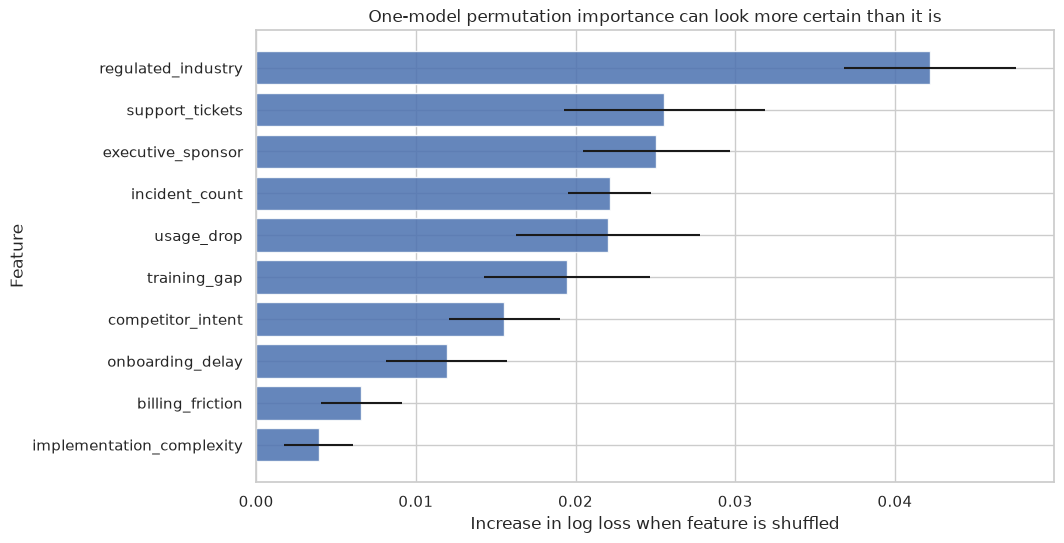

In [5]:
# Section focus: 4. Fit A Baseline Model.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

baseline_model = HistGradientBoostingClassifier(
    max_iter=230,
    learning_rate=0.055,
    max_leaf_nodes=24,
    l2_regularization=0.03,
    random_state=RANDOM_SEED,
)
baseline_model.fit(train_df[FEATURES], train_df[TARGET])
baseline_pred = predict_risk(baseline_model, test_df, FEATURES)

baseline_metrics = pd.DataFrame([classification_metrics(test_df[TARGET], baseline_pred)])
display_table(baseline_metrics)

perm_baseline = permutation_importance(
    baseline_model,
    test_df[FEATURES],
    test_df[TARGET],
    n_repeats=10,
    random_state=RANDOM_SEED,
    scoring='neg_log_loss',
)
baseline_importance = (
    pd.DataFrame({
        'feature': FEATURES,
        'importance_mean': perm_baseline.importances_mean,
        'importance_std': perm_baseline.importances_std,
    })
    .sort_values('importance_mean', ascending=False)
    .assign(rank=lambda d: np.arange(1, len(d) + 1))
)
display_table(baseline_importance)

fig, ax = plt.subplots(figsize=(10.8, 5.6))
plot_imp = baseline_importance.sort_values('importance_mean').tail(10)
ax.barh(plot_imp['feature'], plot_imp['importance_mean'], xerr=plot_imp['importance_std'], color='#4c72b0', alpha=0.86)
ax.set_title('One-model permutation importance can look more certain than it is')
ax.set_xlabel('Increase in log loss when feature is shuffled')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

For Fit A Baseline Model, the explanation earns trust through stability and reviewability, not through a polished chart alone.


### Discussion of The Baseline Explanation

The baseline explanation is a useful starting point. But by itself it answers only one question:

> What did this particular fitted model rely on, evaluated on this particular test set?

It does not answer whether the explanation is stable across plausible retrains. That is what we test next.

## 5. Bootstrap Retraining For Explanation Stability

We will train multiple models on bootstrap samples of the training data. For each model, we compute:

- performance metrics on the fixed test set;
- permutation importance on the fixed test set;
- feature ranks induced by importance.

This separates two types of stability:

1. **Performance stability**: does the model's predictive performance vary much?
2. **Explanation stability**: do the explanations vary much?

A model family can have stable performance but unstable explanation rankings.

In [6]:
# Section focus: 5. Bootstrap Retraining For Explanation Stability.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

B = 24
rng = np.random.default_rng(RANDOM_SEED + 101)
bootstrap_importance_rows = []
bootstrap_metric_rows = []
models = []

for b in range(B):
    boot_idx = rng.choice(train_df.index.to_numpy(), size=len(train_df), replace=True)
    boot = train_df.loc[boot_idx]
    model = HistGradientBoostingClassifier(
        max_iter=210,
        learning_rate=0.055,
        max_leaf_nodes=20 + (b % 3) * 4,
        l2_regularization=0.02 + 0.01 * (b % 4),
        random_state=RANDOM_SEED + b,
    )
    model.fit(boot[FEATURES], boot[TARGET])
    models.append(model)

    pred = predict_risk(model, test_df, FEATURES)
    metrics = classification_metrics(test_df[TARGET], pred)
    metrics['replicate'] = b
    bootstrap_metric_rows.append(metrics)

    perm = permutation_importance(
        model,
        test_df[FEATURES],
        test_df[TARGET],
        n_repeats=5,
        random_state=RANDOM_SEED + 1000 + b,
        scoring='neg_log_loss',
    )
    imp = pd.DataFrame({
        'replicate': b,
        'feature': FEATURES,
        'importance': perm.importances_mean,
    })
    imp['rank'] = imp['importance'].rank(ascending=False, method='average')
    bootstrap_importance_rows.append(imp)

bootstrap_metrics = pd.DataFrame(bootstrap_metric_rows)
bootstrap_importance = pd.concat(bootstrap_importance_rows, ignore_index=True)

metric_summary = bootstrap_metrics.drop(columns='replicate').agg(['mean', 'std', 'min', 'max']).T.reset_index().rename(columns={'index': 'metric'})
importance_summary = (
    bootstrap_importance.groupby('feature')
    .agg(
        mean_importance=('importance', 'mean'),
        std_importance=('importance', 'std'),
        min_importance=('importance', 'min'),
        max_importance=('importance', 'max'),
        mean_rank=('rank', 'mean'),
        rank_std=('rank', 'std'),
        top_5_rate=('rank', lambda s: np.mean(s <= 5)),
    )
    .reset_index()
    .sort_values('mean_importance', ascending=False)
)

display_table(metric_summary)
display_table(importance_summary)

,metric,mean,std,min,max
0,roc_auc,0.779,0.004,0.771,0.786
1,average_precision,0.732,0.006,0.723,0.748
2,brier_score,0.193,0.002,0.189,0.197
3,mean_predicted_risk,0.439,0.007,0.425,0.456


,feature,mean_importance,std_importance,min_importance,max_importance,mean_rank,rank_std,top_5_rate
9,regulated_industry,0.040,0.006,0.027,0.051,1.083,0.282,1.000
4,executive_sponsor,0.026,0.005,0.015,0.036,3.167,1.523,0.917
6,incident_count,0.024,0.004,0.018,0.032,3.458,1.179,0.917
12,usage_drop,0.023,0.007,0.010,0.040,4.583,2.020,0.625
10,support_tickets,0.019,0.006,0.008,0.034,5.167,1.659,0.708
2,competitor_intent,0.019,0.004,0.013,0.026,5.208,1.285,0.542
11,training_gap,0.017,0.007,0.004,0.031,6.000,2.167,0.292
7,onboarding_delay,0.010,0.003,0.005,0.017,8.500,0.933,0.000
1,billing_friction,0.010,0.004,0.004,0.021,8.417,1.283,0.000
5,implementation_complexity,0.005,0.004,-0.001,0.013,9.917,1.248,0.000


This result is an interpretation diagnostic. For Bootstrap Retraining For Explanation Stability, look at whether the explanation is stable, plausible, and useful for stakeholder review. Explanation instability should be visible to the stakeholder, since it changes how much weight the story can carry.


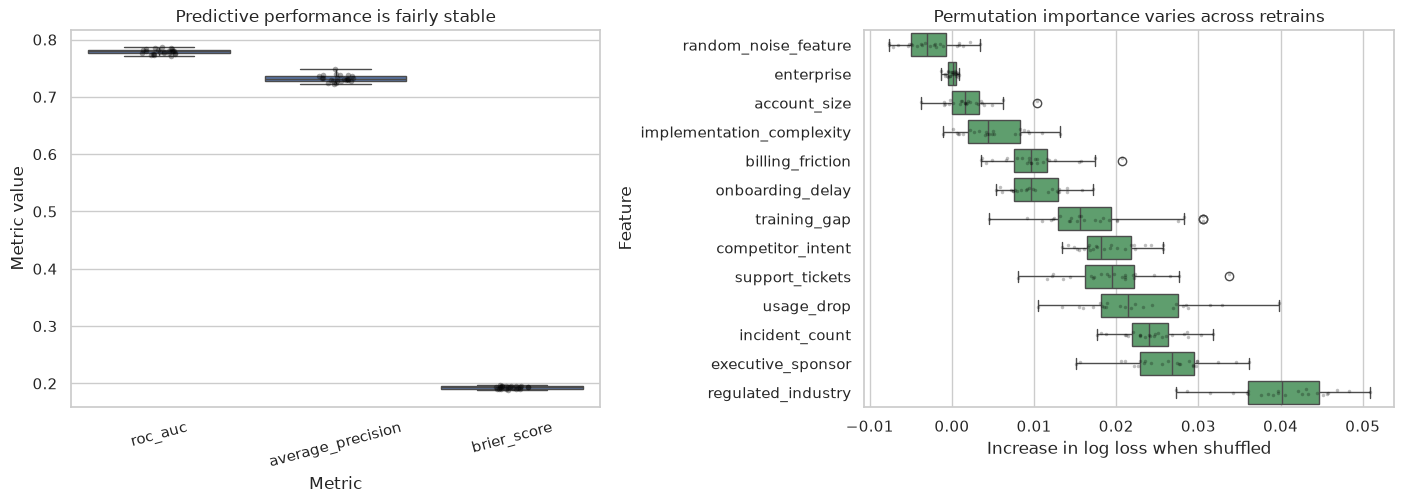

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.2))

sns.boxplot(data=bootstrap_metrics[['roc_auc', 'average_precision', 'brier_score']], ax=axes[0], color='#4c72b0')
sns.stripplot(data=bootstrap_metrics[['roc_auc', 'average_precision', 'brier_score']], ax=axes[0], color='black', alpha=0.35, size=4)
axes[0].set_title('Predictive performance is fairly stable')
axes[0].set_ylabel('Metric value')
axes[0].set_xlabel('Metric')
axes[0].tick_params(axis='x', rotation=15)

plot_stability = bootstrap_importance.merge(importance_summary[['feature', 'mean_importance']], on='feature')
ordered = importance_summary.sort_values('mean_importance', ascending=True)['feature']
sns.boxplot(data=plot_stability, x='importance', y='feature', order=ordered, ax=axes[1], color='#55a868')
sns.stripplot(data=plot_stability, x='importance', y='feature', order=ordered, ax=axes[1], color='black', alpha=0.25, size=2.5)
axes[1].set_title('Permutation importance varies across retrains')
axes[1].set_xlabel('Increase in log loss when shuffled')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()

This result is an interpretation diagnostic. For Bootstrap Retraining For Explanation Stability, look at whether the explanation is stable, plausible, and useful for stakeholder review. The report can use a fragile explanation as a clue, while keeping its limits visible.


### Discussion of Bootstrap Stability

The performance boxplot may look tight while the explanation boxplot is visibly wider. That is a central lesson. Predictive stability and explanation stability are related, but they are not the same object.

The `top_5_rate` column is especially useful for communication. A feature that is in the top five in nearly every retrain is a stable explanatory driver. A feature that sometimes appears important and sometimes disappears should be reported as unstable.

## 6. Rank Agreement Across Explanation Runs

Now we quantify agreement between feature rankings. We compare every bootstrap importance ranking to the baseline ranking.

Two useful diagnostics are:

- Spearman rank correlation across all features;
- Jaccard overlap of the top five features.

,replicate,spearman_with_baseline,top5_jaccard_with_baseline,top5_features
0,0,0.940,0.667,"regulated_industry, support_tickets, incident_count, competitor_intent, executive_sponsor"
1,1,0.962,1.000,"regulated_industry, executive_sponsor, incident_count, support_tickets, usage_drop"
2,2,0.951,1.000,"regulated_industry, executive_sponsor, incident_count, usage_drop, support_tickets"
3,3,0.973,1.000,"regulated_industry, executive_sponsor, support_tickets, usage_drop, incident_count"
4,4,0.786,0.429,"regulated_industry, training_gap, usage_drop, competitor_intent, incident_count"
5,5,0.929,1.000,"regulated_industry, incident_count, usage_drop, executive_sponsor, support_tickets"
6,6,0.764,0.667,"regulated_industry, usage_drop, incident_count, competitor_intent, executive_sponsor"
7,7,0.901,0.667,"regulated_industry, executive_sponsor, incident_count, competitor_intent, support_tickets"
8,8,0.929,0.667,"regulated_industry, executive_sponsor, usage_drop, support_tickets, competitor_intent"
9,9,0.885,0.667,"regulated_industry, executive_sponsor, incident_count, usage_drop, competitor_intent"


,quantity,mean,std,min,max
0,spearman_with_baseline,0.900,0.052,0.764,0.973
1,top5_jaccard_with_baseline,0.730,0.172,0.429,1.000


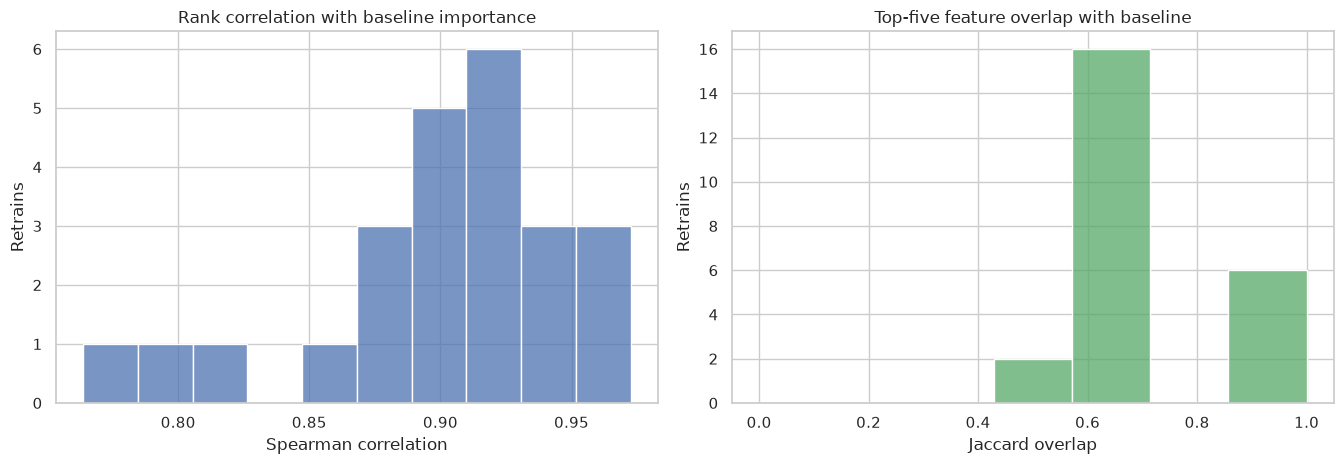

In [8]:
# Section focus: 6. Rank Agreement Across Explanation Runs.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

baseline_rank_map = baseline_importance.set_index('feature')['rank'].to_dict()
baseline_top5 = set(baseline_importance.head(5)['feature'])
rank_agreement_rows = []

for b, group in bootstrap_importance.groupby('replicate'):
    replicate_rank = group.set_index('feature')['rank']
    aligned_features = list(baseline_rank_map.keys())
    rho = spearmanr(
        [baseline_rank_map[f] for f in aligned_features],
        [replicate_rank.loc[f] for f in aligned_features],
    ).correlation
    rep_top5 = set(group.sort_values('rank').head(5)['feature'])
    rank_agreement_rows.append({
        'replicate': b,
        'spearman_with_baseline': rho,
        'top5_jaccard_with_baseline': jaccard(baseline_top5, rep_top5),
        'top5_features': ', '.join(group.sort_values('rank').head(5)['feature']),
    })

rank_agreement = pd.DataFrame(rank_agreement_rows)
display_table(rank_agreement.head(10), max_width='620px')
display_table(rank_agreement[['spearman_with_baseline', 'top5_jaccard_with_baseline']].agg(['mean', 'std', 'min', 'max']).T.reset_index().rename(columns={'index': 'quantity'}))

fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.8))
sns.histplot(rank_agreement['spearman_with_baseline'], bins=10, ax=axes[0], color='#4c72b0')
axes[0].set_title('Rank correlation with baseline importance')
axes[0].set_xlabel('Spearman correlation')
axes[0].set_ylabel('Retrains')

sns.histplot(rank_agreement['top5_jaccard_with_baseline'], bins=np.linspace(0, 1, 8), ax=axes[1], color='#55a868')
axes[1].set_title('Top-five feature overlap with baseline')
axes[1].set_xlabel('Jaccard overlap')
axes[1].set_ylabel('Retrains')

plt.tight_layout()
plt.show()

Use the explanation as a stress test of the model narrative. In Rank Agreement Across Explanation Runs, the displayed reasons should make sense with the data-generating story and the operating decision. When explanation views disagree, the communication should become more careful.


### Discussion of Rank Agreement

If the rank correlations are high but the top-five overlap is moderate, the broad story may be stable while exact ordering remains unstable. If both are low, the explanation is not ready for a high-confidence narrative.

A governance report should avoid statements like "the most important feature is X" when several features trade places across retrains. A better statement is: "the stable explanatory cluster contains X, Y, and Z; their exact order varies."

## 7. A Simple Rashomon Diagnostic Across Model Classes

Bootstrap retraining studies one model family. A broader stability check compares several good models. If two models have similar performance but different explanations, we are seeing a practical Rashomon issue.

We fit three model classes:

- logistic regression with standardized features;
- histogram gradient boosting;
- random forest.

Then we compare performance and permutation importance.

In [9]:
# Section focus: 7. A Simple Rashomon Diagnostic Across Model Classes.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

model_specs = {
    'Logistic regression': LogisticRegression(max_iter=2000, C=0.75, random_state=RANDOM_SEED),
    'Gradient boosting': HistGradientBoostingClassifier(max_iter=230, learning_rate=0.055, max_leaf_nodes=24, l2_regularization=0.03, random_state=RANDOM_SEED),
    'Random forest': RandomForestClassifier(n_estimators=260, min_samples_leaf=18, max_features='sqrt', random_state=RANDOM_SEED, n_jobs=-1),
}

class_model_rows = []
class_importance_rows = []
class_models = {}

for name, model in model_specs.items():
    if name == 'Logistic regression':
        scaler = StandardScaler().fit(train_df[FEATURES])
        X_train = scaler.transform(train_df[FEATURES])
        X_test = scaler.transform(test_df[FEATURES])
        model.fit(X_train, train_df[TARGET])
        pred = model.predict_proba(X_test)[:, 1]
        class_models[name] = (model, scaler)
        perm = permutation_importance(
            model,
            X_test,
            test_df[TARGET],
            n_repeats=8,
            random_state=RANDOM_SEED + 400,
            scoring='neg_log_loss',
        )
    else:
        model.fit(train_df[FEATURES], train_df[TARGET])
        pred = predict_risk(model, test_df, FEATURES)
        class_models[name] = (model, None)
        perm = permutation_importance(
            model,
            test_df[FEATURES],
            test_df[TARGET],
            n_repeats=8,
            random_state=RANDOM_SEED + 400,
            scoring='neg_log_loss',
        )
    metrics = classification_metrics(test_df[TARGET], pred)
    metrics['model_class'] = name
    class_model_rows.append(metrics)
    for feature, imp in zip(FEATURES, perm.importances_mean):
        class_importance_rows.append({'model_class': name, 'feature': feature, 'importance': imp})

class_metrics = pd.DataFrame(class_model_rows).sort_values('roc_auc', ascending=False)
class_importance = pd.DataFrame(class_importance_rows)
class_importance['rank'] = class_importance.groupby('model_class')['importance'].rank(ascending=False, method='average')

display_table(class_metrics)
class_top = class_importance.sort_values(['model_class', 'rank']).groupby('model_class').head(6)
display_table(class_top.sort_values(['model_class', 'rank']))

,roc_auc,average_precision,brier_score,mean_predicted_risk,model_class
0,0.805,0.769,0.177,0.441,Logistic regression
2,0.799,0.757,0.181,0.442,Random forest
1,0.785,0.736,0.188,0.440,Gradient boosting


,model_class,feature,importance,rank
15,Gradient boosting,regulated_industry,0.040,1.000
20,Gradient boosting,support_tickets,0.028,2.000
16,Gradient boosting,executive_sponsor,0.027,3.000
17,Gradient boosting,usage_drop,0.024,4.000
18,Gradient boosting,training_gap,0.020,5.000
21,Gradient boosting,incident_count,0.020,6.000
2,Logistic regression,regulated_industry,0.037,1.000
3,Logistic regression,executive_sponsor,0.029,2.000
4,Logistic regression,usage_drop,0.022,3.000
8,Logistic regression,incident_count,0.021,4.000


This result is an interpretation diagnostic. For A Simple Rashomon Diagnostic Across Model Classes, look at whether the explanation is stable, plausible, and useful for stakeholder review. The model story needs qualification when a small change in the explanation setup changes the takeaway.


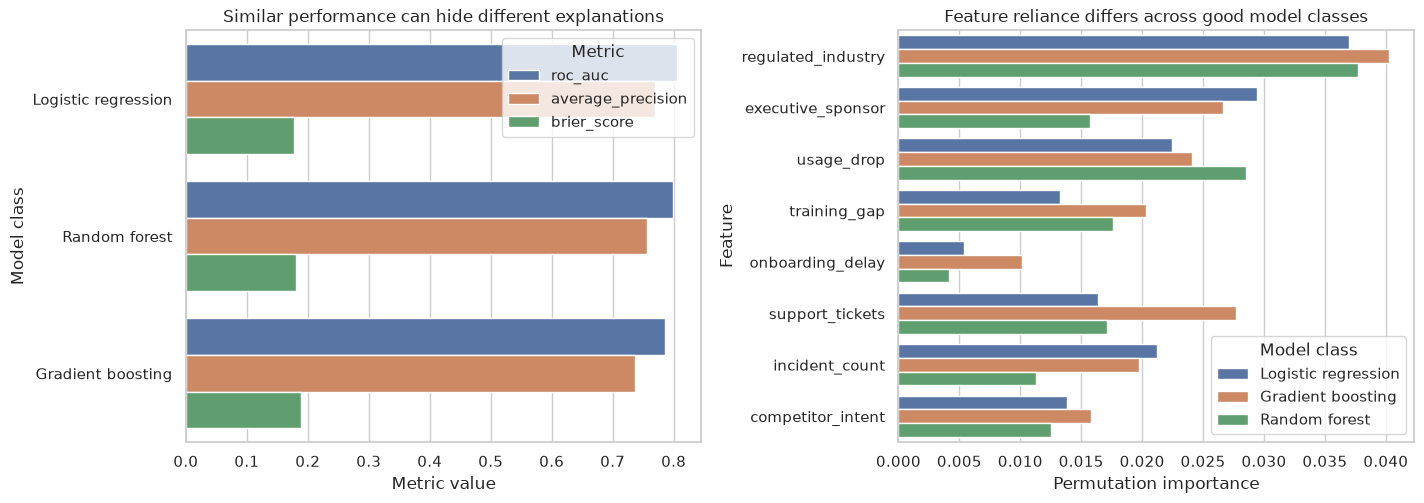

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14.4, 5.2))

metric_plot = class_metrics.melt(id_vars='model_class', value_vars=['roc_auc', 'average_precision', 'brier_score'], var_name='metric', value_name='value')
sns.barplot(data=metric_plot, x='value', y='model_class', hue='metric', ax=axes[0], palette='deep')
axes[0].set_title('Similar performance can hide different explanations')
axes[0].set_xlabel('Metric value')
axes[0].set_ylabel('Model class')
axes[0].legend(title='Metric')

plot_class_imp = class_importance[class_importance['feature'].isin(importance_summary.head(8)['feature'])].copy()
sns.barplot(data=plot_class_imp, x='importance', y='feature', hue='model_class', ax=axes[1], palette='deep')
axes[1].set_title('Feature reliance differs across good model classes')
axes[1].set_xlabel('Permutation importance')
axes[1].set_ylabel('Feature')
axes[1].legend(title='Model class', loc='lower right')

plt.tight_layout()
plt.show()

This result is an interpretation diagnostic. For A Simple Rashomon Diagnostic Across Model Classes, look at whether the explanation is stable, plausible, and useful for stakeholder review. Use the variation across samples and neighborhoods to decide how strongly the explanation can be stated.


### Discussion of The Rashomon Diagnostic

If the three model classes have similar performance but assign different importance to correlated features, the organization should not pretend there is one inevitable explanatory story. It should report the stable parts and flag model-class-sensitive parts.

Explanations can be useful, and they should be audited like other estimates.

## 8. Local Explanation Stability For A Focal Account

Global stability can be acceptable while local explanations remain unstable. We choose a high-risk focal account near the review threshold and fit local linear surrogates for each bootstrap model.

For each retrain, we approximate the model locally around the focal account with a weighted ridge model:

$$
\widehat f_b(x) \approx \alpha_b + \sum_j \beta_{bj} z_j.
$$

Then we examine the distribution of local coefficients $\beta_{bj}$.

In [11]:
# Section focus: 8. Local Explanation Stability For A Focal Account.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

test_pred = pd.Series(baseline_pred, index=test_df.index)
focal_index = test_pred.sub(0.58).abs().sort_values().index[0]
focal = test_df.loc[focal_index]

local_pool = test_df.sample(min(900, len(test_df)), random_state=RANDOM_SEED).copy()
if focal_index not in local_pool.index:
    local_pool = pd.concat([local_pool, test_df.loc[[focal_index]]])

local_scaler = StandardScaler().fit(train_df[FEATURES])
X_local = local_scaler.transform(local_pool[FEATURES])
focal_scaled = local_scaler.transform(pd.DataFrame([focal[FEATURES]], columns=FEATURES))[0]
distances = np.sqrt(((X_local - focal_scaled) ** 2).sum(axis=1))
bandwidth = np.quantile(distances, 0.35)
weights = np.exp(-(distances ** 2) / (2 * bandwidth ** 2))

local_rows = []
local_fit_rows = []
for b, model in enumerate(models):
    local_target = predict_risk(model, local_pool, FEATURES)
    surrogate = Ridge(alpha=0.40)
    surrogate.fit(X_local, local_target, sample_weight=weights)
    local_fit_rows.append({'replicate': b, 'weighted_r2': surrogate.score(X_local, local_target, sample_weight=weights)})
    for feature, coef in zip(FEATURES, surrogate.coef_):
        local_rows.append({'replicate': b, 'feature': feature, 'local_coefficient': coef})

local_coef = pd.DataFrame(local_rows)
local_fit = pd.DataFrame(local_fit_rows)
baseline_local_target = predict_risk(baseline_model, local_pool, FEATURES)
baseline_surrogate = Ridge(alpha=0.40).fit(X_local, baseline_local_target, sample_weight=weights)
baseline_local = pd.DataFrame({'feature': FEATURES, 'baseline_local_coefficient': baseline_surrogate.coef_})

local_summary = (
    local_coef.groupby('feature')
    .agg(
        mean_local_coefficient=('local_coefficient', 'mean'),
        std_local_coefficient=('local_coefficient', 'std'),
        p10=('local_coefficient', lambda s: np.quantile(s, 0.10)),
        p90=('local_coefficient', lambda s: np.quantile(s, 0.90)),
        positive_rate=('local_coefficient', lambda s: np.mean(s > 0)),
    )
    .reset_index()
    .merge(baseline_local, on='feature')
    .assign(abs_mean=lambda d: d['mean_local_coefficient'].abs())
    .sort_values('abs_mean', ascending=False)
)

focal_summary = pd.DataFrame([{
    'focal_index': focal_index,
    'observed_outcome': int(focal[TARGET]),
    'baseline_predicted_risk': float(test_pred.loc[focal_index]),
    **{feature: focal[feature] for feature in FEATURES},
}])

display_table(focal_summary, max_width='620px')
display_table(local_fit[['weighted_r2']].agg(['mean', 'std', 'min', 'max']).T.reset_index().rename(columns={'index': 'quantity'}))
display_table(local_summary.drop(columns='abs_mean'))

,focal_index,observed_outcome,baseline_predicted_risk,account_size,enterprise,regulated_industry,executive_sponsor,usage_drop,training_gap,onboarding_delay,support_tickets,incident_count,billing_friction,competitor_intent,implementation_complexity,random_noise_feature
0,5221,1,0.580,1.325,0.000,0.000,1.000,0.649,0.671,6.128,8.000,1.000,0.393,0.514,0.394,0.215


,quantity,mean,std,min,max
0,weighted_r2,0.784,0.015,0.756,0.813


,feature,mean_local_coefficient,std_local_coefficient,p10,p90,positive_rate,baseline_local_coefficient
9,regulated_industry,0.092,0.009,0.080,0.102,1.000,0.092
12,usage_drop,0.077,0.012,0.063,0.090,1.000,0.067
4,executive_sponsor,-0.069,0.008,-0.079,-0.060,0.000,-0.074
11,training_gap,0.057,0.008,0.048,0.064,1.000,0.055
10,support_tickets,0.053,0.010,0.038,0.064,1.000,0.054
2,competitor_intent,0.049,0.007,0.043,0.057,1.000,0.049
6,incident_count,0.042,0.006,0.034,0.050,1.000,0.046
7,onboarding_delay,0.040,0.007,0.031,0.050,1.000,0.035
1,billing_friction,0.032,0.008,0.023,0.043,1.000,0.026
8,random_noise_feature,0.009,0.006,0.002,0.017,0.958,0.011


Use the explanation as a stress test of the model narrative. In Local Explanation Stability For A Focal Account, the displayed reasons should make sense with the data-generating story and the operating decision. Method-level disagreement is a reason to review the case before using the explanation operationally.


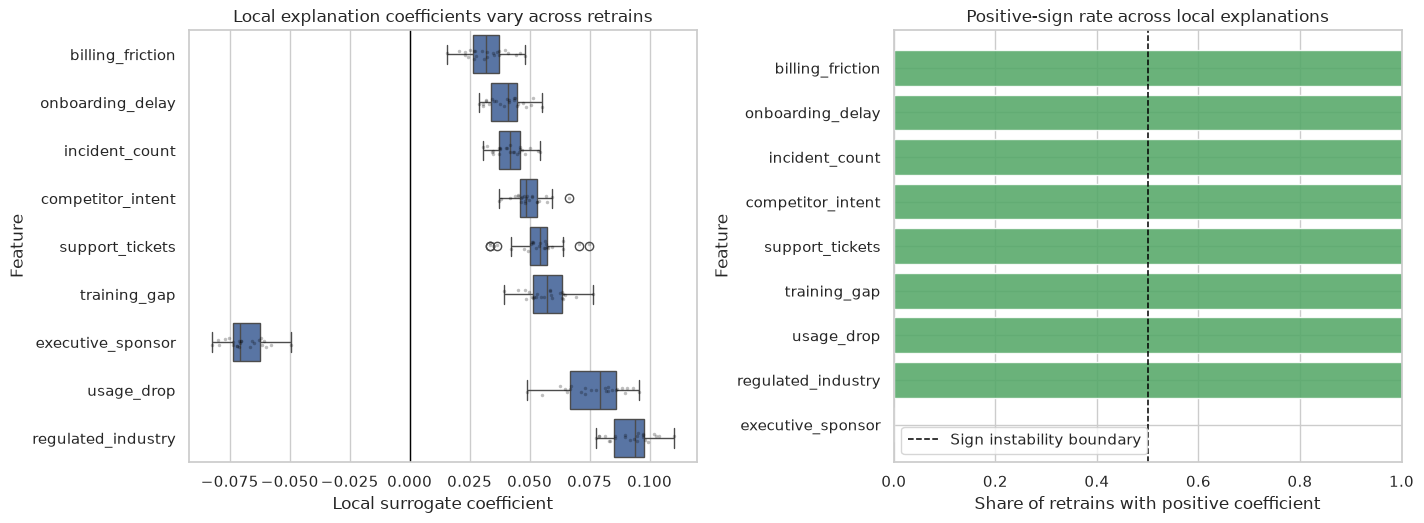

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14.4, 5.4))

plot_local = local_summary.head(9)['feature']
sns.boxplot(data=local_coef[local_coef['feature'].isin(plot_local)], x='local_coefficient', y='feature', order=list(plot_local[::-1]), ax=axes[0], color='#4c72b0')
sns.stripplot(data=local_coef[local_coef['feature'].isin(plot_local)], x='local_coefficient', y='feature', order=list(plot_local[::-1]), ax=axes[0], color='black', alpha=0.25, size=2.5)
axes[0].axvline(0, color='black', linewidth=1.0)
axes[0].set_title('Local explanation coefficients vary across retrains')
axes[0].set_xlabel('Local surrogate coefficient')
axes[0].set_ylabel('Feature')

sign_plot = local_summary.head(9).sort_values('positive_rate')
colors = np.where(sign_plot['positive_rate'].between(0.25, 0.75), '#c44e52', '#55a868')
axes[1].barh(sign_plot['feature'], sign_plot['positive_rate'], color=colors, alpha=0.88)
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1.1, label='Sign instability boundary')
axes[1].set_title('Positive-sign rate across local explanations')
axes[1].set_xlabel('Share of retrains with positive coefficient')
axes[1].set_ylabel('Feature')
axes[1].set_xlim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

For Local Explanation Stability For A Focal Account, read the explanation as something a stakeholder may challenge. Stability, clarity, and sensitivity all matter.


### Discussion of Local Stability

A local explanation should be handled carefully when signs or magnitudes vary across retrains. If a feature has a positive rate near 0.5, the local story is unstable: sometimes the surrogate says the feature pushes risk up, and sometimes it says the opposite.

The local surrogate fit also matters. A low local $R^2$ means the local linear explanation is only a rough approximation of the black-box model near the focal case.

## 9. Partial Dependence Stability Bands

Partial dependence curves can also shift across retrains. For feature $x_j$, partial dependence is

$$
\widehat g_b(t)=\frac{1}{n}\sum_{i=1}^{n}\widehat f_b(t, x_{i,-j}).
$$

We compute this curve for `usage_drop` across bootstrap models and report a stability band.

,usage_drop,pd_mean,pd_p10,pd_p90,pd_min,pd_max,baseline_pd
0,0.082,0.303,0.257,0.345,0.231,0.378,0.304
6,0.232,0.355,0.327,0.387,0.306,0.393,0.359
12,0.383,0.411,0.394,0.424,0.389,0.428,0.410
18,0.534,0.483,0.461,0.500,0.455,0.511,0.485
24,0.685,0.529,0.507,0.552,0.491,0.574,0.519
30,0.835,0.555,0.515,0.603,0.491,0.626,0.545


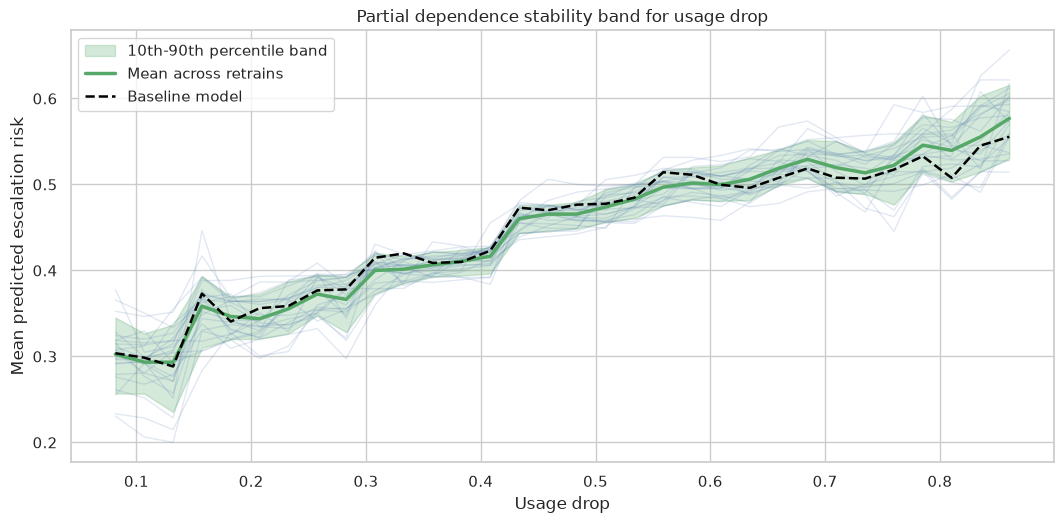

In [13]:
# Section focus: 9. Partial Dependence Stability Bands.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def partial_dependence_values(model, data, features, feature, grid):
    """Carry out the partial dependence values step used in the 13. Explanation Stability Across Resamples and Retrains workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    data : object
        Input data set used by this step of the notebook.
    features : object
        Feature column names or feature matrix used by the model.
    feature : object
        Column or variable name used to select information from the input table.
    grid : object
        Grid of candidate values used for plotting, tuning, or sensitivity analysis.
    
    Returns
    -------
    object
        Array-like values produced by the calculation.
    """
    values = []
    base = data[features].copy()
    for value in grid:
        modified = base.copy()
        modified[feature] = value
        values.append(float(predict_risk(model, modified, features).mean()))
    return np.array(values)

pd_grid = np.linspace(test_df['usage_drop'].quantile(0.03), test_df['usage_drop'].quantile(0.97), 32)
pd_rows = []
for b, model in enumerate(models):
    vals = partial_dependence_values(model, test_df, FEATURES, 'usage_drop', pd_grid)
    for x, y in zip(pd_grid, vals):
        pd_rows.append({'replicate': b, 'usage_drop': x, 'partial_dependence': y})
pd_stability = pd.DataFrame(pd_rows)
pd_summary = (
    pd_stability.groupby('usage_drop')
    .agg(
        pd_mean=('partial_dependence', 'mean'),
        pd_p10=('partial_dependence', lambda s: np.quantile(s, 0.10)),
        pd_p90=('partial_dependence', lambda s: np.quantile(s, 0.90)),
        pd_min=('partial_dependence', 'min'),
        pd_max=('partial_dependence', 'max'),
    )
    .reset_index()
)
base_pd = partial_dependence_values(baseline_model, test_df, FEATURES, 'usage_drop', pd_grid)
pd_summary['baseline_pd'] = base_pd

display_table(pd_summary.iloc[::6])

fig, ax = plt.subplots(figsize=(10.8, 5.4))
for _, group in pd_stability.groupby('replicate'):
    ax.plot(group['usage_drop'], group['partial_dependence'], color='#4c72b0', alpha=0.16, linewidth=1)
ax.fill_between(pd_summary['usage_drop'], pd_summary['pd_p10'], pd_summary['pd_p90'], color='#55a868', alpha=0.25, label='10th-90th percentile band')
ax.plot(pd_summary['usage_drop'], pd_summary['pd_mean'], color='#55a868', linewidth=2.5, label='Mean across retrains')
ax.plot(pd_summary['usage_drop'], pd_summary['baseline_pd'], color='black', linestyle='--', linewidth=1.8, label='Baseline model')
ax.set_title('Partial dependence stability band for usage drop')
ax.set_xlabel('Usage drop')
ax.set_ylabel('Mean predicted escalation risk')
ax.legend()
plt.tight_layout()
plt.show()

The explanation result should be compared with the decision story. In Partial Dependence Stability Bands, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. When the explanation is thin, the final recommendation becomes harder to justify.


### Discussion of Curve Stability

The mean curve gives the broad relationship. The band shows how much that relationship moves across retrains. If the band is narrow, the curve is a stable explanation. If the band is wide or changes shape, the curve should be communicated with caution.

A professional plot should not hide this band when the curve is used to guide business decisions.

## 10. Stability Report Card

We can summarize explanation stability using a small report card. The thresholds below are illustrative. In a real organization, they should depend on model risk, decision stakes, and governance requirements.

,diagnostic,value,rule_of_thumb,status
0,Performance stability,0.005,Coefficient of variation below 0.03 is usually reassuring,Pass
1,Global rank agreement,0.900,Mean Spearman correlation above 0.75 is strong,Pass
2,Top-five explanation overlap,0.730,Mean Jaccard overlap above 0.60 supports a stable top-feature story,Pass
3,Local sign instability,0.000,Zero or one unstable signs among top local features is easiest to communicate,Pass
4,Partial-dependence band width,0.053,Lower is better; compare to the risk scale and business tolerance,Review


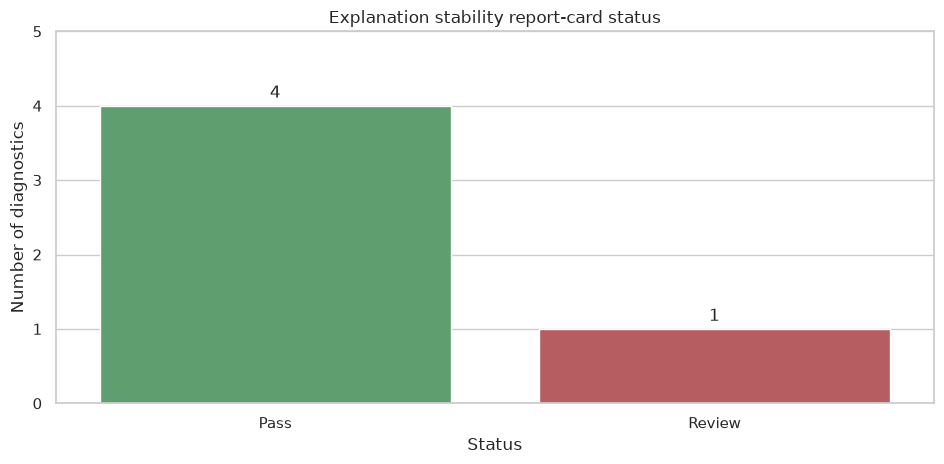

In [14]:
# Section focus: 10. Stability Report Card.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

performance_cv = bootstrap_metrics['roc_auc'].std() / bootstrap_metrics['roc_auc'].mean()
mean_rank_corr = rank_agreement['spearman_with_baseline'].mean()
mean_top5_overlap = rank_agreement['top5_jaccard_with_baseline'].mean()
unstable_local_features = int((local_summary.head(8)['positive_rate'].between(0.25, 0.75)).sum())
pd_band_width = float((pd_summary['pd_p90'] - pd_summary['pd_p10']).mean())

report_card = pd.DataFrame([
    {
        'diagnostic': 'Performance stability',
        'value': performance_cv,
        'rule_of_thumb': 'Coefficient of variation below 0.03 is usually reassuring',
        'status': 'Pass' if performance_cv < 0.03 else 'Review',
    },
    {
        'diagnostic': 'Global rank agreement',
        'value': mean_rank_corr,
        'rule_of_thumb': 'Mean Spearman correlation above 0.75 is strong',
        'status': 'Pass' if mean_rank_corr > 0.75 else 'Review',
    },
    {
        'diagnostic': 'Top-five explanation overlap',
        'value': mean_top5_overlap,
        'rule_of_thumb': 'Mean Jaccard overlap above 0.60 supports a stable top-feature story',
        'status': 'Pass' if mean_top5_overlap > 0.60 else 'Review',
    },
    {
        'diagnostic': 'Local sign instability',
        'value': unstable_local_features,
        'rule_of_thumb': 'Zero or one unstable signs among top local features is easiest to communicate',
        'status': 'Pass' if unstable_local_features <= 1 else 'Review',
    },
    {
        'diagnostic': 'Partial-dependence band width',
        'value': pd_band_width,
        'rule_of_thumb': 'Lower is better; compare to the risk scale and business tolerance',
        'status': 'Pass' if pd_band_width < 0.045 else 'Review',
    },
])
display_table(report_card, max_width='680px')

fig, ax = plt.subplots(figsize=(9.6, 4.8))
status_counts = report_card['status'].value_counts().reindex(['Pass', 'Review'], fill_value=0).reset_index()
status_counts.columns = ['status', 'count']
sns.barplot(data=status_counts, x='status', y='count', hue='status', palette={'Pass': '#55a868', 'Review': '#c44e52'}, legend=False, ax=ax)
ax.set_title('Explanation stability report-card status')
ax.set_xlabel('Status')
ax.set_ylabel('Number of diagnostics')
ax.set_ylim(0, max(3, status_counts['count'].max() + 1))
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
plt.tight_layout()
plt.show()

Stability Report Card is useful only if the explanation remains credible under reasonable modeling choices.


### Discussion of The Report Card

A report card should not be treated as a universal pass/fail device. Its value is that it forces explicit communication about uncertainty in explanations. If performance is stable but explanations are unstable, the team can still deploy the model while avoiding overly specific causal-sounding narratives.

A good governance sentence is:

> Predictive performance is stable across retrains, but exact feature ordering is moderately variable. We will communicate the stable feature cluster rather than a single definitive ranking.

## 11. Practical Checklist For Explanation Stability

Before communicating an explanation in a high-stakes decision workflow, ask:

| Check | Why it matters |
|---|---|
| Does performance remain stable across resamples? | Unstable models produce unstable explanations |
| Do the same features appear in the top explanation set? | Prevents overclaiming one arbitrary feature ranking |
| Do local explanation signs agree across retrains? | Prevents contradictory case-level narratives |
| Do effect curves keep the same shape? | Prevents policy recommendations based on fragile curves |
| Do similar-performing model classes tell different stories? | Detects practical Rashomon behavior |
| Are unstable explanations labeled as unstable? | Supports auditability and honest stakeholder communication |

## 12. Key Takeaways

- Explanations are outputs of a modeling pipeline, not fixed facts.
- Stable performance does not guarantee stable explanations.
- Correlated features can substitute for one another across retrains.
- Global explanations, local explanations, and effect curves can have different stability profiles.
- Explanation uncertainty should be shown when explanations support decisions.
- In governance settings, report stable explanatory clusters rather than overclaiming exact ranks.

## References

- Dong, J., & Rudin, C. (2019). *Variable importance clouds: A way to explore variable importance for the set of good models*. arXiv. [https://doi.org/10.48550/arxiv.1901.03209](https://doi.org/10.48550/arxiv.1901.03209)
- Fisher, A., Rudin, C., & Dominici, F. (2018). *All models are wrong, but many are useful: Learning a variable's importance by studying an entire class of prediction models simultaneously*. arXiv. [https://doi.org/10.48550/arxiv.1801.01489](https://doi.org/10.48550/arxiv.1801.01489)
- Hancox-Li, L. (2020). *Robustness in machine learning explanations*. Proceedings of the 2020 Conference on Fairness, Accountability, and Transparency, 640-647. [https://doi.org/10.1145/3351095.3372836](https://doi.org/10.1145/3351095.3372836)
- Ning, Y., Ong, M. E. H., Chakraborty, B., Goldstein, B. A., Ting, D. S. W., Vaughan, R., & Liu, N. (2022). *Shapley variable importance cloud for interpretable machine learning*. Patterns, 3(4), 100452. [https://doi.org/10.1016/j.patter.2022.100452](https://doi.org/10.1016/j.patter.2022.100452)
- Rudin, C., Chen, C., Chen, Z., Huang, H., Semenova, L., & Zhong, C. (2022). *Interpretable machine learning: Fundamental principles and 10 grand challenges*. Statistics Surveys, 16, 1-85. [https://doi.org/10.1214/21-ss133](https://doi.org/10.1214/21-ss133)
